# **Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
sns.set_palette('viridis')

In [3]:
from sklearn import set_config
set_config(transform_output="pandas")

In [4]:
import warnings
warnings.filterwarnings("ignore")

# **Load Dataset**

[Dataset - Spaceship Titanic](https://www.kaggle.com/competitions/spaceship-titanic/data?select=train.csv)

In [5]:
df = pd.read_csv('train.csv')

# **Data Analysis**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB


In [7]:
df.isna().sum()

,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


<Axes: >

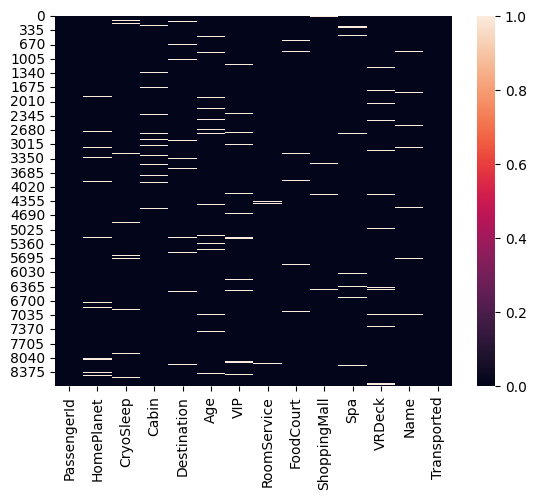

In [8]:
sns.heatmap(df.isna())

The data is missing randomly, no pattern is seen.

In [9]:
df.nunique()

,0
PassengerId,8693
HomePlanet,3
CryoSleep,2
Cabin,6560
Destination,3
Age,80
VIP,2
RoomService,1273
FoodCourt,1507
ShoppingMall,1115


There are several types of features:

- **categorical**: Name, Cabin, HomePlanet, Destination
- **continuous**: VRDeck, Spa, ShoppingMall, FoodCourt, RoomService, Age
- **binary**: CryoSleep, VIP, Transported

In [10]:
df.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In this spaceship are all categories of people - newborns(0 years), young, and elders. However, the majority are young - 3 quarters are equal or less than 38 years.

The larger number of people hadn't paid for any services - more than 50%. However, the largest amount spent is almost 30k.

In [11]:
num_cols = df.select_dtypes(include='number').columns.tolist()

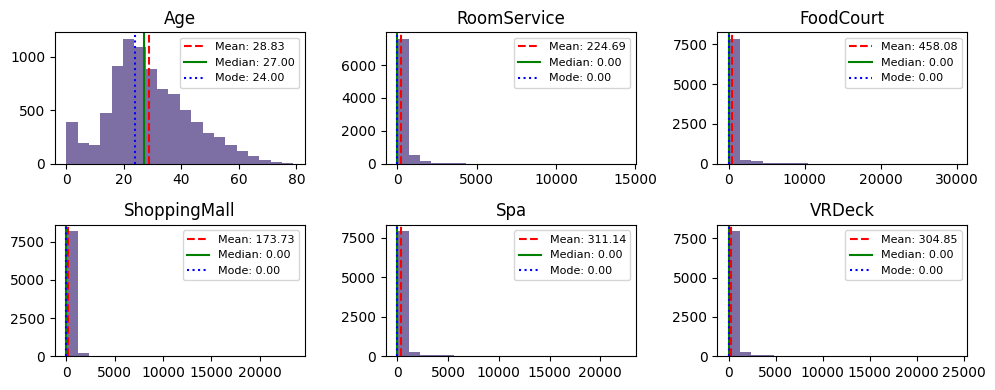

In [12]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 4))
axs = axs.flatten()

for col, ax in zip(num_cols, axs):
    data = df[col].dropna()

    ax.hist(data, bins=20, alpha=0.7)

    mean = data.mean()
    median = data.median()
    mode = data.mode()
    if len(mode) > 0:
        mode = mode.iloc[0]
    else:
        mode = np.nan

    ax.axvline(mean, color='red', linestyle='dashed', linewidth=1.5, label=f'Mean: {mean:.2f}')
    ax.axvline(median, color='green', linestyle='solid', linewidth=1.5, label=f'Median: {median:.2f}')
    ax.axvline(mode, color='blue', linestyle='dotted', linewidth=1.5, label=f'Mode: {mode:.2f}')

    ax.set_title(col)
    ax.legend(fontsize=8)

for ax in axs[len(num_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

For services - the same thing we noticed earlier.

The age median, mean, and mode are pretty close, as well as the data looks quite bell-shaped, even though it is right-skewed.

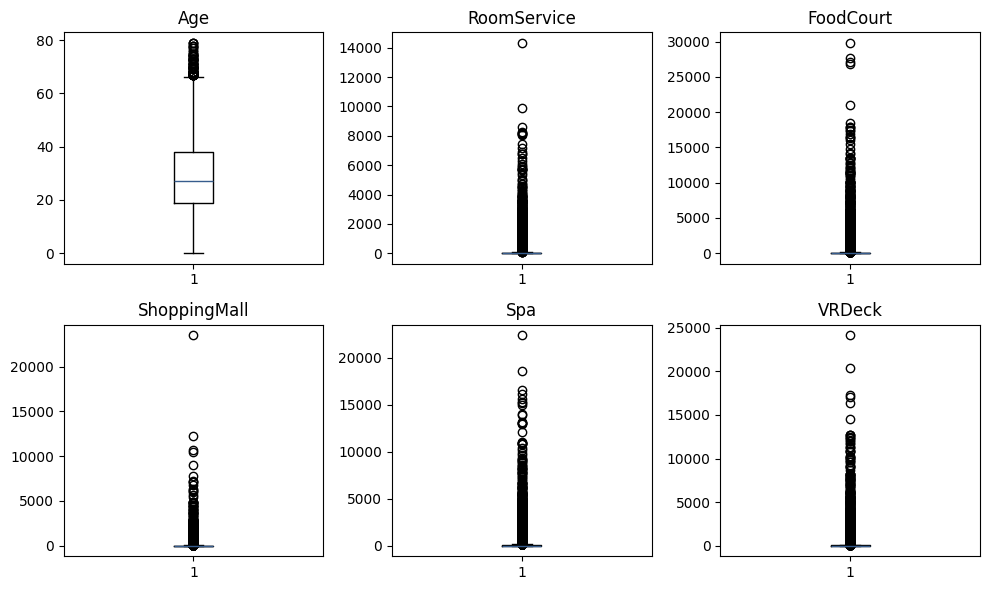

In [13]:
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(10, 6))
axs = axs.flatten()

for col, ax in zip(num_cols, axs):
    data = df[col].dropna()

    ax.boxplot(data)

    ax.set_title(col)

for ax in axs[len(num_cols):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

As mentioned earlier, the majority of people hadn't used services at all.  So, almost any person who has used services is viewed as an outlier.

Usually, people were aged 0-67, however some older people also were present. A typical pasanger was 27 years old.

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
[cat_cols.remove(e) for e in ['PassengerId','Cabin', 'Name']]

[None, None, None]

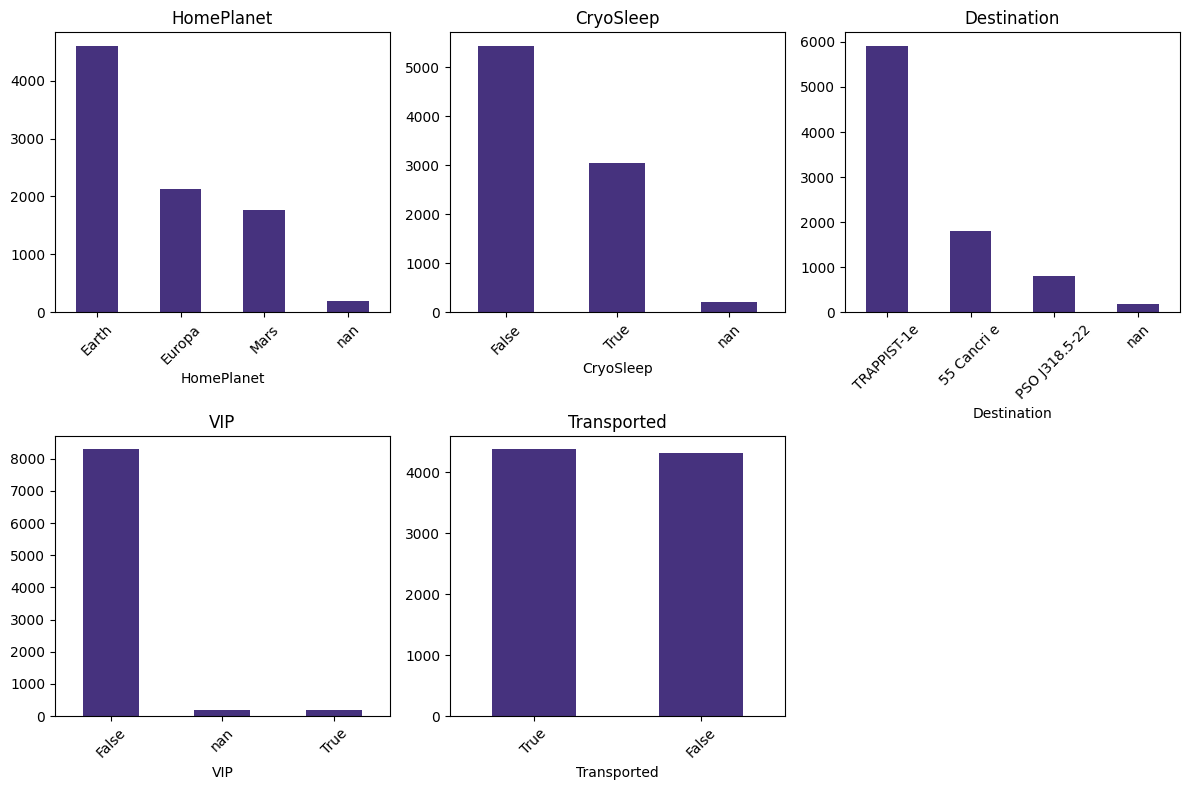

In [16]:
ncols = 3
nrows = math.ceil(len(cat_cols) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  df[col].value_counts(dropna=False).plot.bar(ax=axes[i])
  axes[i].set_title(col)
  axes[i].tick_params(axis='x', rotation=45)

[fig.delaxes(axes[j]) for j in range(i + 1, len(axes))]

plt.tight_layout()
plt.show()

Many of the people weren't VIP, The most popular Home Planet was Earth, while the most popular destination was TRAPPIST-1e.

An equal number of people were and weren't transported to the destination.

In [17]:
df['Transported'] = df['Transported'].astype(int)

In [18]:
corr_matrix = df.dropna()[df.select_dtypes(include='number').columns].corr()

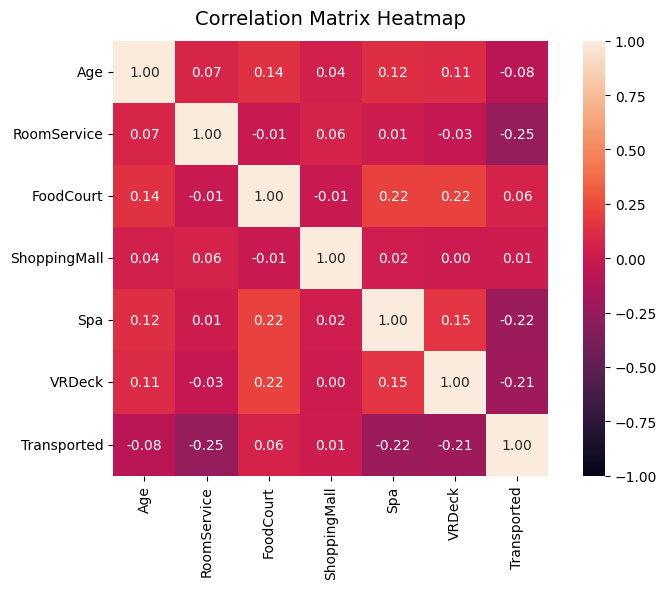

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

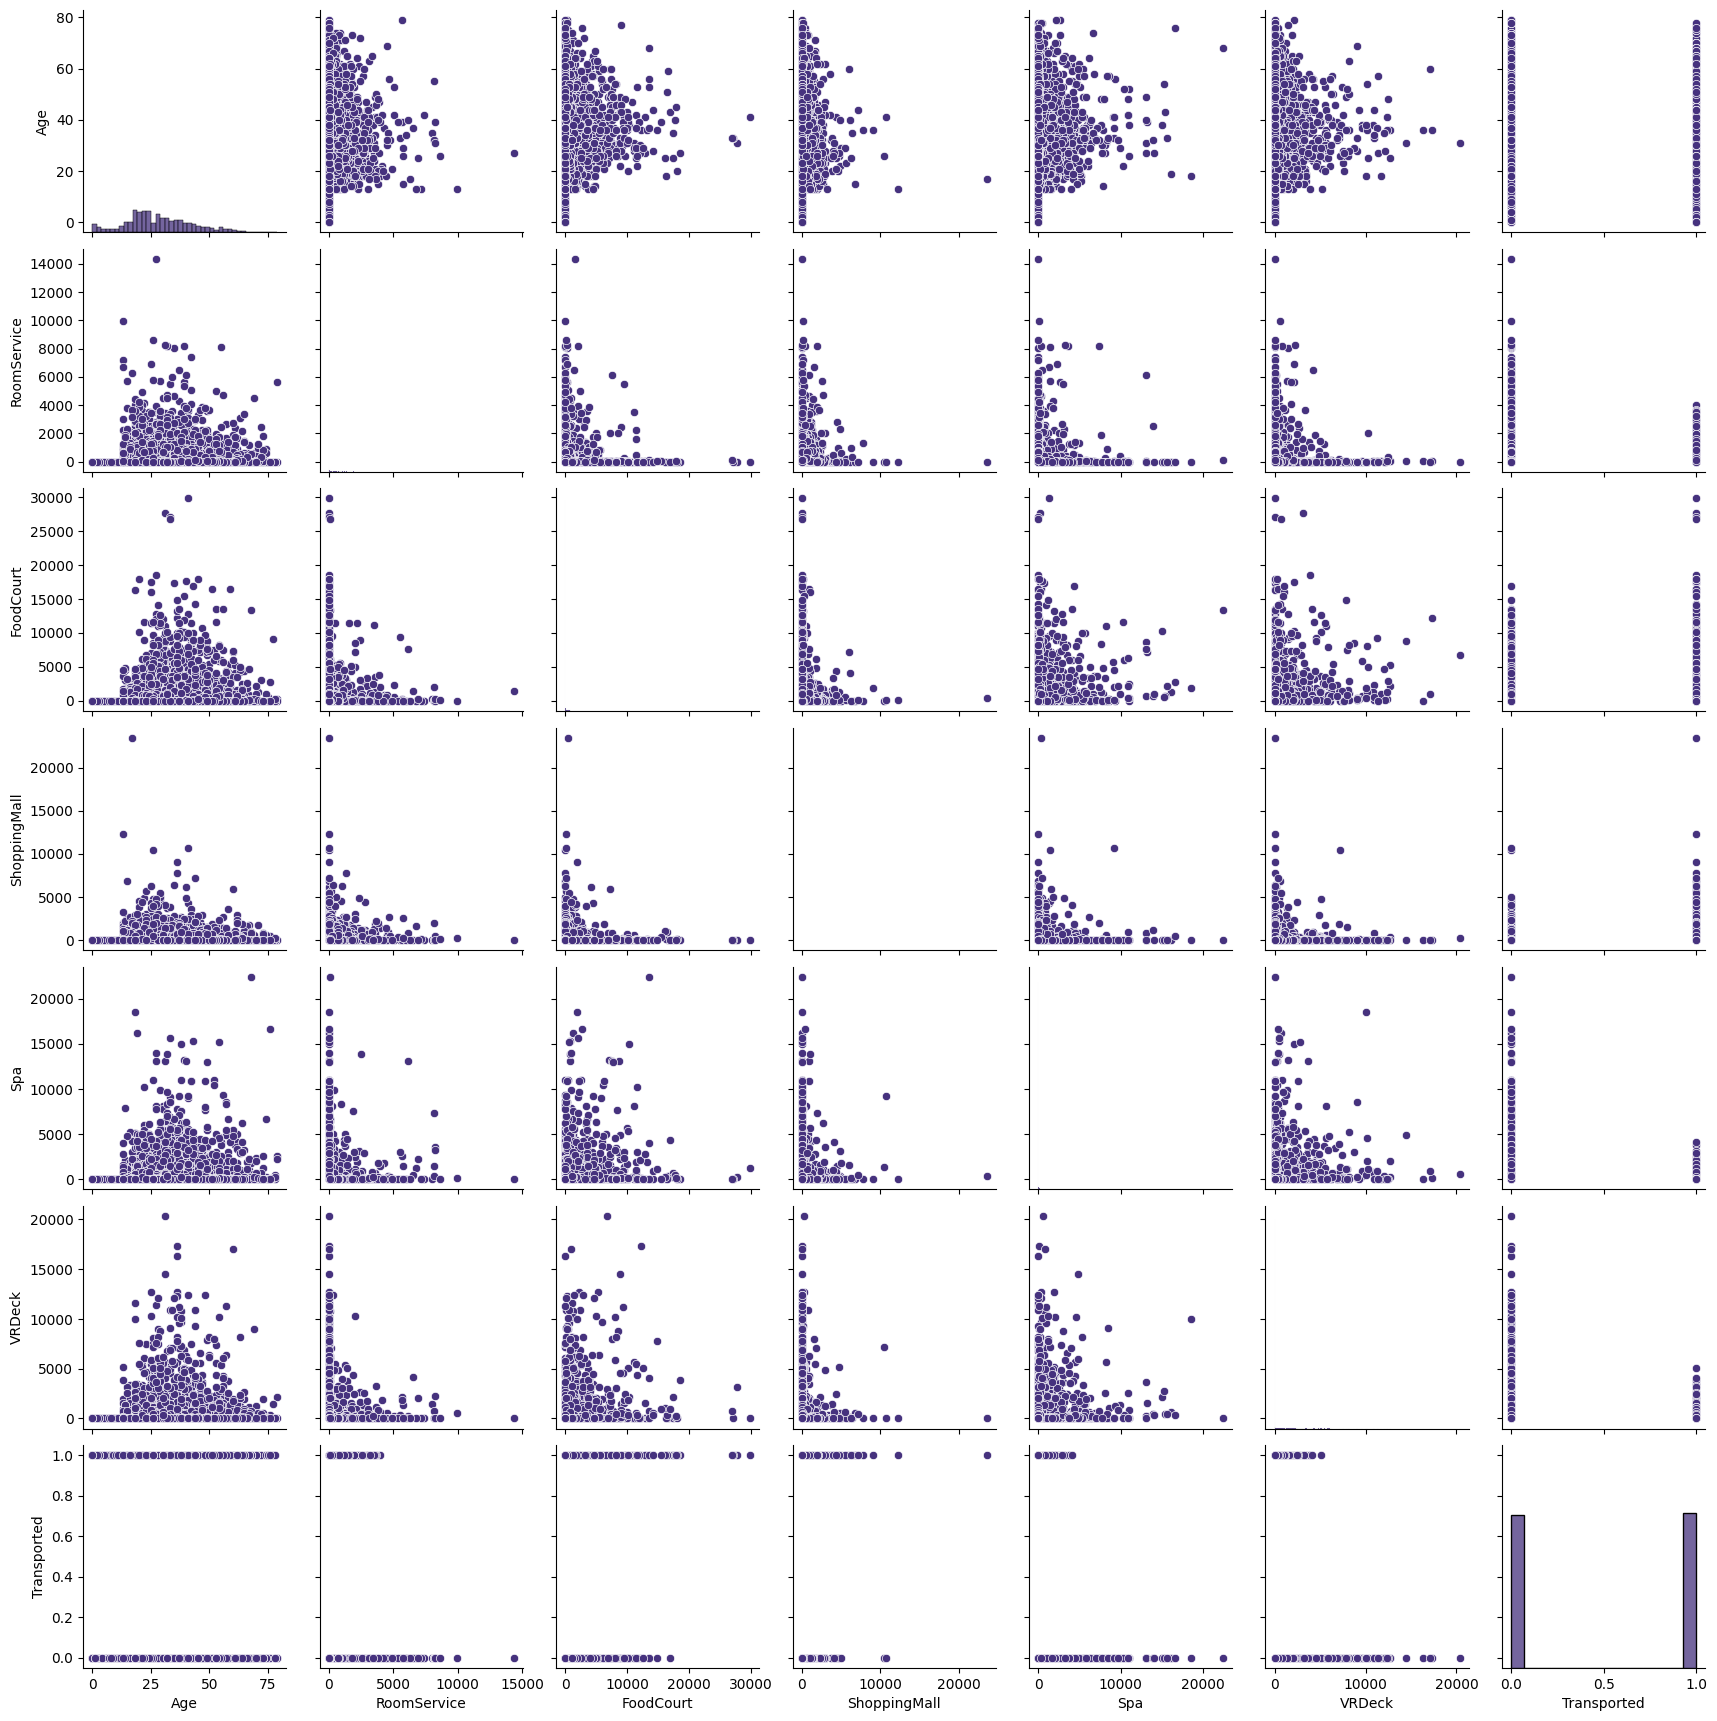

In [20]:
num_df = df.select_dtypes(include="number").dropna()

sns.pairplot(num_df)

In [21]:
df.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,0
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,1


In [22]:
corr = df[df.select_dtypes(include='number').columns].corr()

In [23]:
pd.DataFrame(np.abs(corr)).sort_values('Transported', ascending=False)['Transported'].head()

,Transported
Transported,1.000000
RoomService,0.244611
Spa,0.221131
VRDeck,0.207075
Age,0.075026


# **Data Preprocessing**

## **Feature Engineering**

In [6]:
df["CryoSleep"] = df["CryoSleep"].astype('Int64')
df["VIP"] = df["VIP"].astype('Int64')

In [7]:
split = df["PassengerId"].str.split("_", expand=True)

df["Group"] = split[0].astype(int)
df["Id"] = split[1].astype(int)

In [8]:
df["CabinMissing"] = df["Cabin"].isna().astype(int)

In [9]:
split = df["Cabin"].str.split("/", expand=True)

df["Deck"] = split[0]
df["CabinNumber"] = split[1].astype('Int64')
df["Side"] = split[2]

In [10]:
split = df["Name"].str.split(" ", expand=True)

split.nunique()

,0
0,2706
1,2217


In [11]:
df['FamilyName'] = split[1]

In [12]:
df.drop(['Cabin', 'PassengerId', 'Name'], axis=1, inplace=True)

In [13]:
df["HomePlanetMissing"] = df["HomePlanet"].isna().astype(int)
df["DestinationMissing"] = df["Destination"].isna().astype(int)

## **Encoding 1**

In [14]:
df = pd.get_dummies(
    df,
    columns=["HomePlanet", "Destination"],
    dtype=int
)

In [15]:
df["Side"] = df["Side"].map({"P": 0, "S": 1}).astype('Int64')

## **Splitting**

In [16]:
from sklearn.model_selection import train_test_split, StratifiedKFold

In [17]:
X = df.drop('Transported', axis=1)
y = df['Transported']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [19]:
X_trains, X_tests, y_trains, y_tests = [], [], [], []

for train_idx, test_idx in cv.split(X, y):
    X_trains.append(X.iloc[train_idx].copy())
    X_tests.append(X.iloc[test_idx].copy())
    y_trains.append(y.iloc[train_idx].copy())
    y_tests.append(y.iloc[test_idx].copy())

## **Encoding 2**

In [20]:
from sklearn.preprocessing import TargetEncoder

In [21]:
pd.concat([df.nunique(), df.dtypes], axis=1)

,0,1
CryoSleep,2,Int64
Age,80,float64
VIP,2,Int64
RoomService,1273,float64
FoodCourt,1507,float64
ShoppingMall,1115,float64
Spa,1327,float64
VRDeck,1306,float64
Transported,2,bool
Group,6217,int64


In [22]:
tg_enc_cols = [
    'Deck',
    'FamilyName',
    'Group',
    'CabinNumber'
]

In [23]:
for (X_train, y_train, X_test) in zip(X_trains, y_trains, X_tests):
  tg_enc = TargetEncoder()
  X_train[tg_enc_cols] = tg_enc.fit_transform(X_train[tg_enc_cols], y_train)
  X_test[tg_enc_cols] = tg_enc.transform(X_test[tg_enc_cols])

## **Models**

In [24]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 252.4/252.4 MB 1.5 MB/s eta 0:00:00


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

In [26]:
from sklearn.metrics import f1_score, accuracy_score, recall_score, precision_score, roc_auc_score

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.base import clone

In [28]:
models = [
    LogisticRegression(random_state=42),
    RandomForestClassifier(n_estimators=200, random_state=42),
    SVC(kernel='poly', random_state=42),
    SVC(kernel='rbf', random_state=42),
    GaussianNB(),
    KNeighborsClassifier(),
    xgb.XGBClassifier()
]

In [29]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [30]:
def plot_conf_matrix(y_tests, y_preds, title, labels):
  fig, axs = plt.subplots(ncols=len(y_tests), figsize=(15, 15))

  for i, (y_test, y_pred) in enumerate(zip(y_tests, y_preds)):
      cm = confusion_matrix(y_test, y_pred)
      disp = ConfusionMatrixDisplay(
          confusion_matrix=cm,
          display_labels=labels
      )
      disp.plot(ax=axs[i], colorbar=False)

  plt.title(title)
  plt.tight_layout()

## **Data Imputation**

In [31]:
from sklearn.impute import KNNImputer
from sklearn.impute import SimpleImputer

In [32]:
missing_vals_cols = [
  'CryoSleep',
  'Age',
  'VIP',
  'RoomService',
  'FoodCourt',
  'ShoppingMall',
  'Spa',
  'VRDeck',
  'CabinNumber',
  'Side'
]

In [51]:
df.isna().sum()

,0
CryoSleep,217
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208
Spa,183
VRDeck,188
Transported,0
Group,0


In [33]:
all_cols = df.drop('Transported', axis=1).columns

In [34]:
from sklearn.compose import ColumnTransformer

In [35]:
preps = [
    ('knn_imputer',KNNImputer(n_neighbors=5)),
    ('median_imputer',SimpleImputer(strategy='most_frequent'))
]

preprocessors = [
  ColumnTransformer(
    transformers=[(i, j, missing_vals_cols)],
    remainder="passthrough",
    verbose_feature_names_out=False
) for (i,j) in preps]

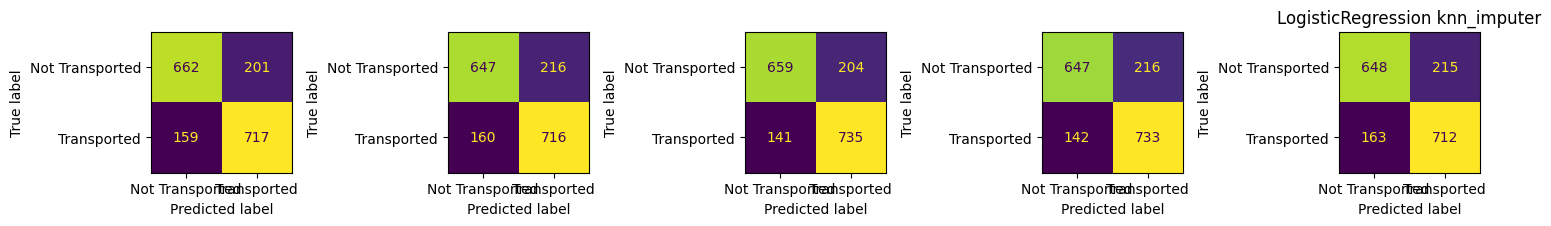

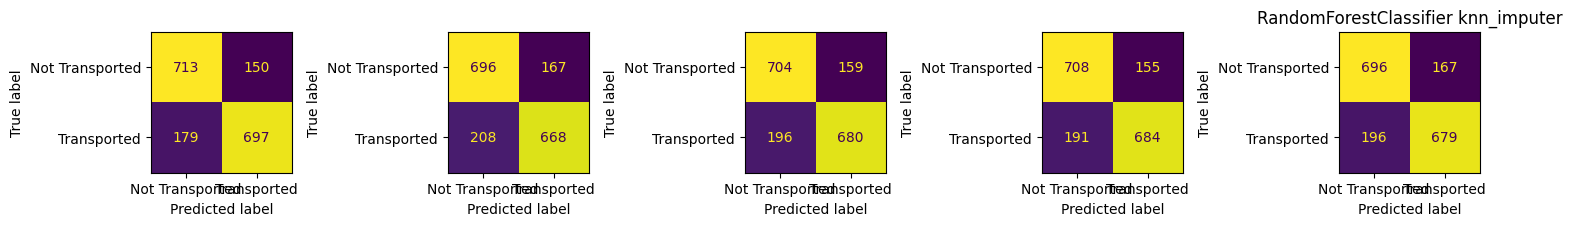

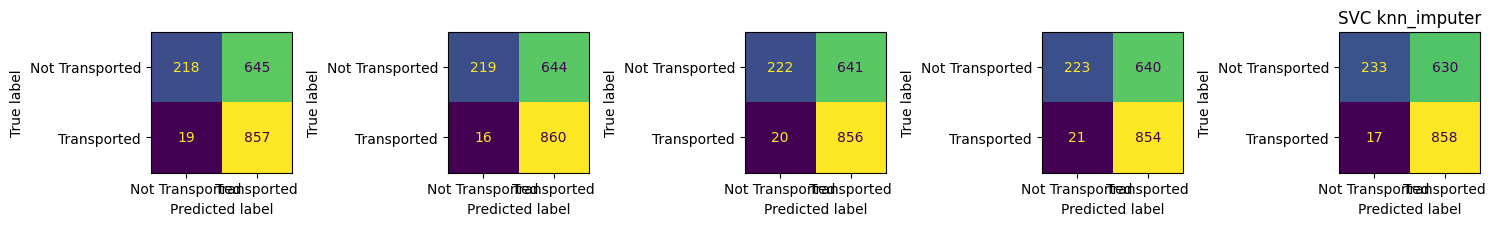

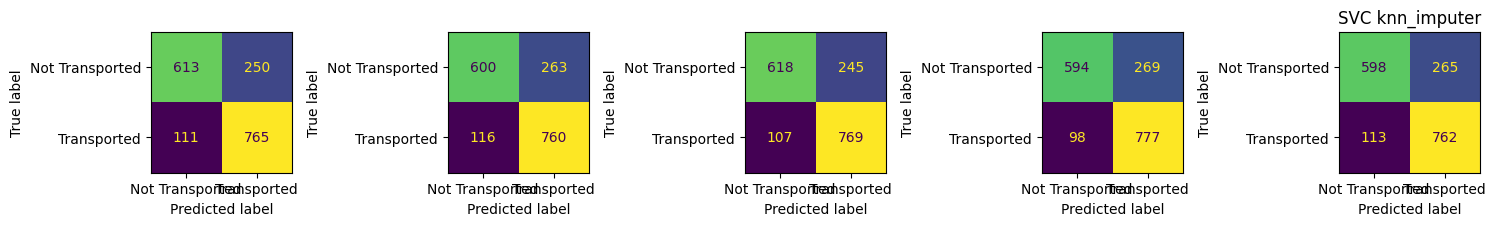

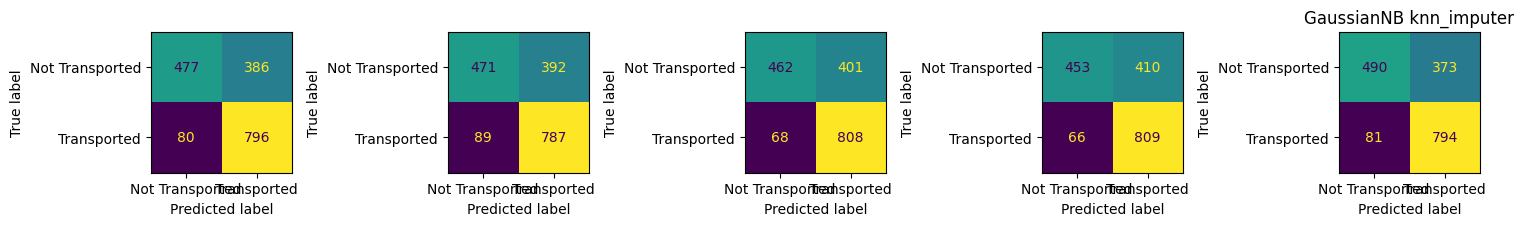

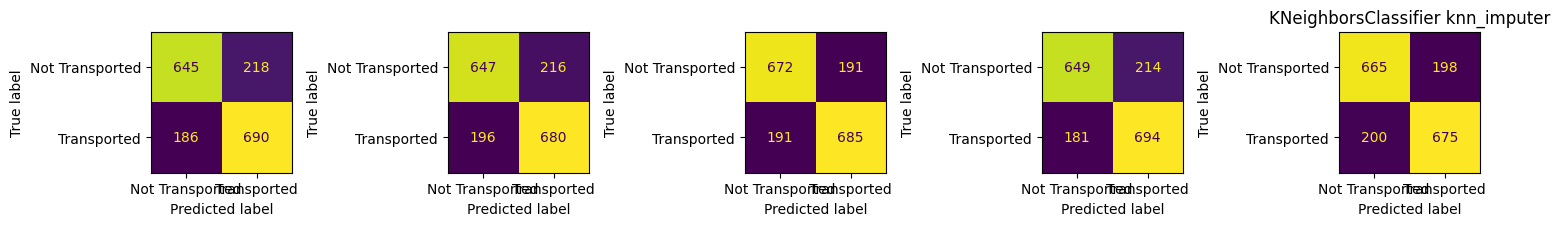

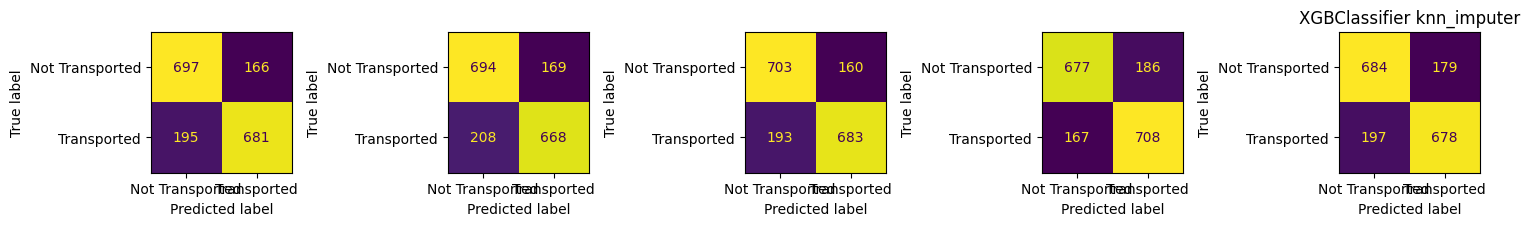

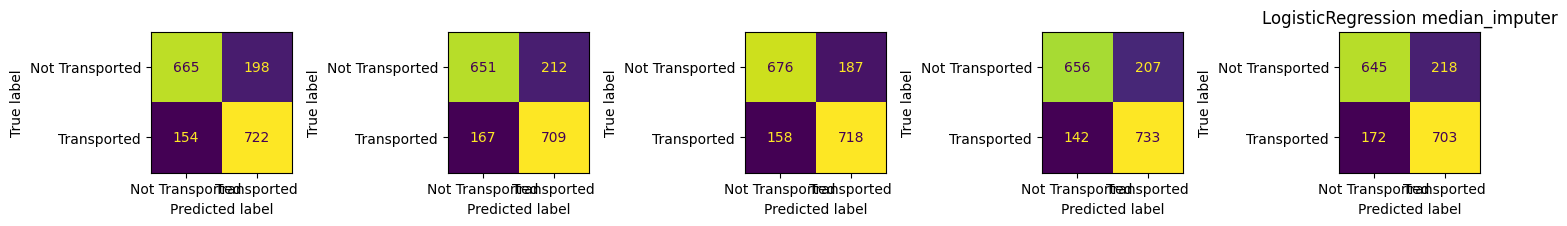

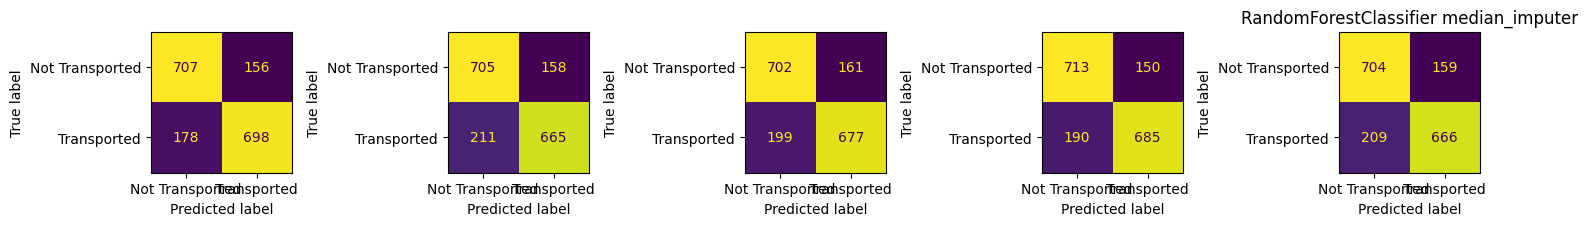

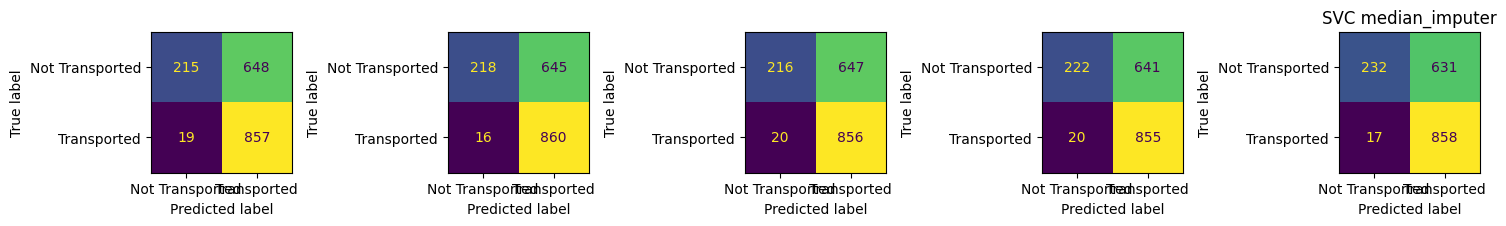

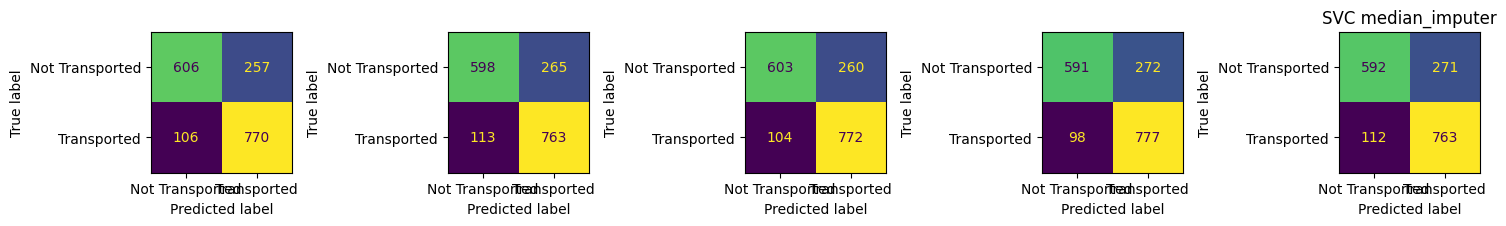

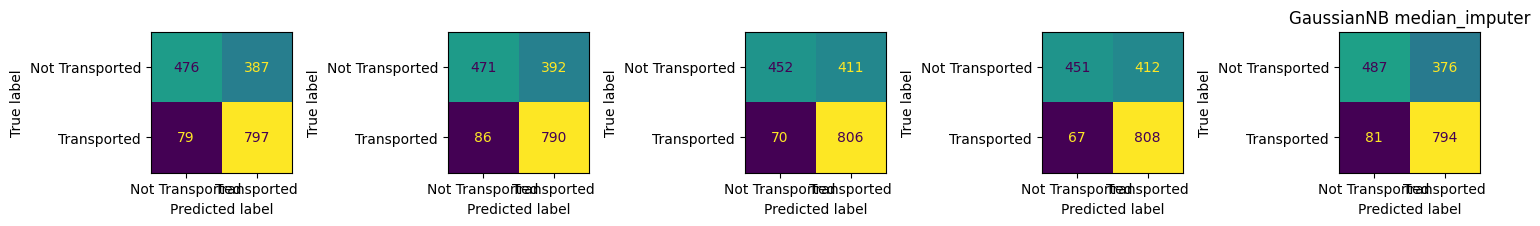

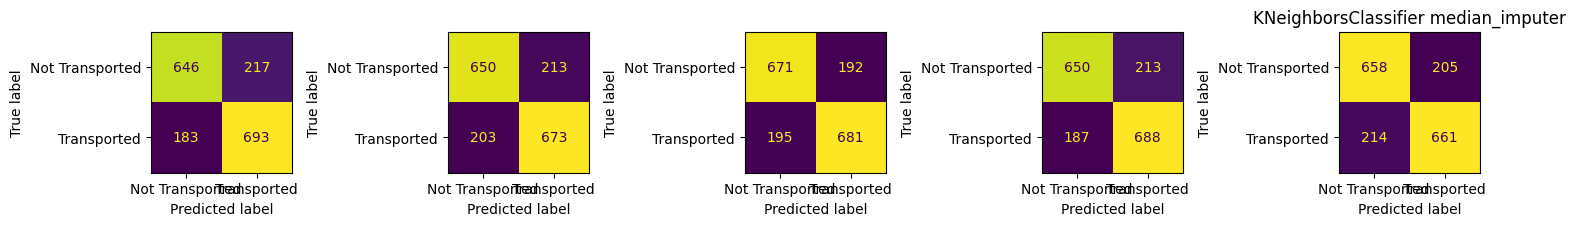

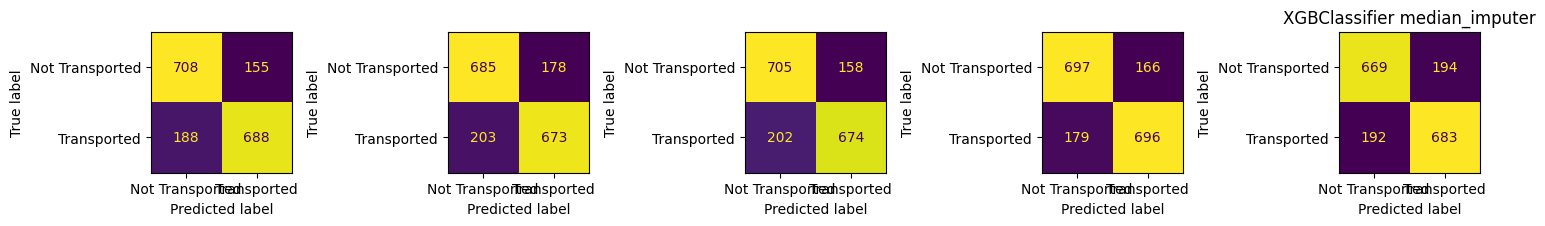

In [57]:
scores = []

for preprocessor in preprocessors:
  for model in models:
    pipeline = Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    y_preds = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)
      y_preds.append(y_pred)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))

      if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
      elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)
      else:
        raise ValueError(
            f"{type(model).__name__} does not provide a suitable ROC AUC score."
        )

      roc_auc.append(roc_auc_score(y_test, y_score))

    model_name = type(model).__name__
    prep_name = preprocessor.transformers[0][0]

    plot_conf_matrix(y_tests, y_preds, f'{model_name} {prep_name}',
                     ['Not Transported', 'Transported'])

    scores.append({
    "model": model_name,
    "preprocessor": prep_name,
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    })

In [58]:
pd.DataFrame(scores)

,model,preprocessor,accuracy,f1,recall,precision,roc_auc
0,LogisticRegression,knn_imputer,0.790981,0.799049,0.825263,0.774499,0.875936
1,RandomForestClassifier,knn_imputer,0.796618,0.794019,0.778438,0.810250,0.880352
2,SVC,knn_imputer,0.621190,0.722417,0.978757,0.572485,0.833460
3,SVC,knn_imputer,0.788680,0.806698,0.875516,0.747957,0.848483
4,GaussianNB,knn_imputer,0.730128,0.772983,0.912290,0.670661,0.854969
5,KNeighborsClassifier,knn_imputer,0.770965,0.774755,0.782092,0.767663,0.836539
6,XGBClassifier,knn_imputer,0.790636,0.789682,0.780727,0.799076,0.881350
7,LogisticRegression,median_imputer,0.791210,0.797991,0.818868,0.778211,0.874896
8,RandomForestClassifier,median_imputer,0.796273,0.792883,0.774553,0.812172,0.880826
9,SVC,median_imputer,0.619925,0.721797,0.978986,0.571628,0.820963


Looking at the results for both of the imputers, they practically have the same effect on the models' performance. However, having the first slightly outperforming 4 out of 6, we'll go with the first one - KNNImputer.

Also, SVC with poly kernel has the lowest score, so it will be dropped. Also, Gaussian Naive Bayes is not as good as others - drop it.

In [36]:
models.pop(4)
models.pop(2)

SVC(kernel='poly', random_state=42)

In [37]:
for X_train, y_train, X_test in zip(X_trains, y_trains, X_tests):
  knn_imputer = KNNImputer()
  X_train[missing_vals_cols] = knn_imputer.fit_transform(X_train[missing_vals_cols], y_train)
  X_test[missing_vals_cols] = knn_imputer.transform(X_test[missing_vals_cols])

### Check correlation one more time

In [61]:
corr_matrix = pd.concat([X_trains[0],y_trains[0]],axis=1).corr()

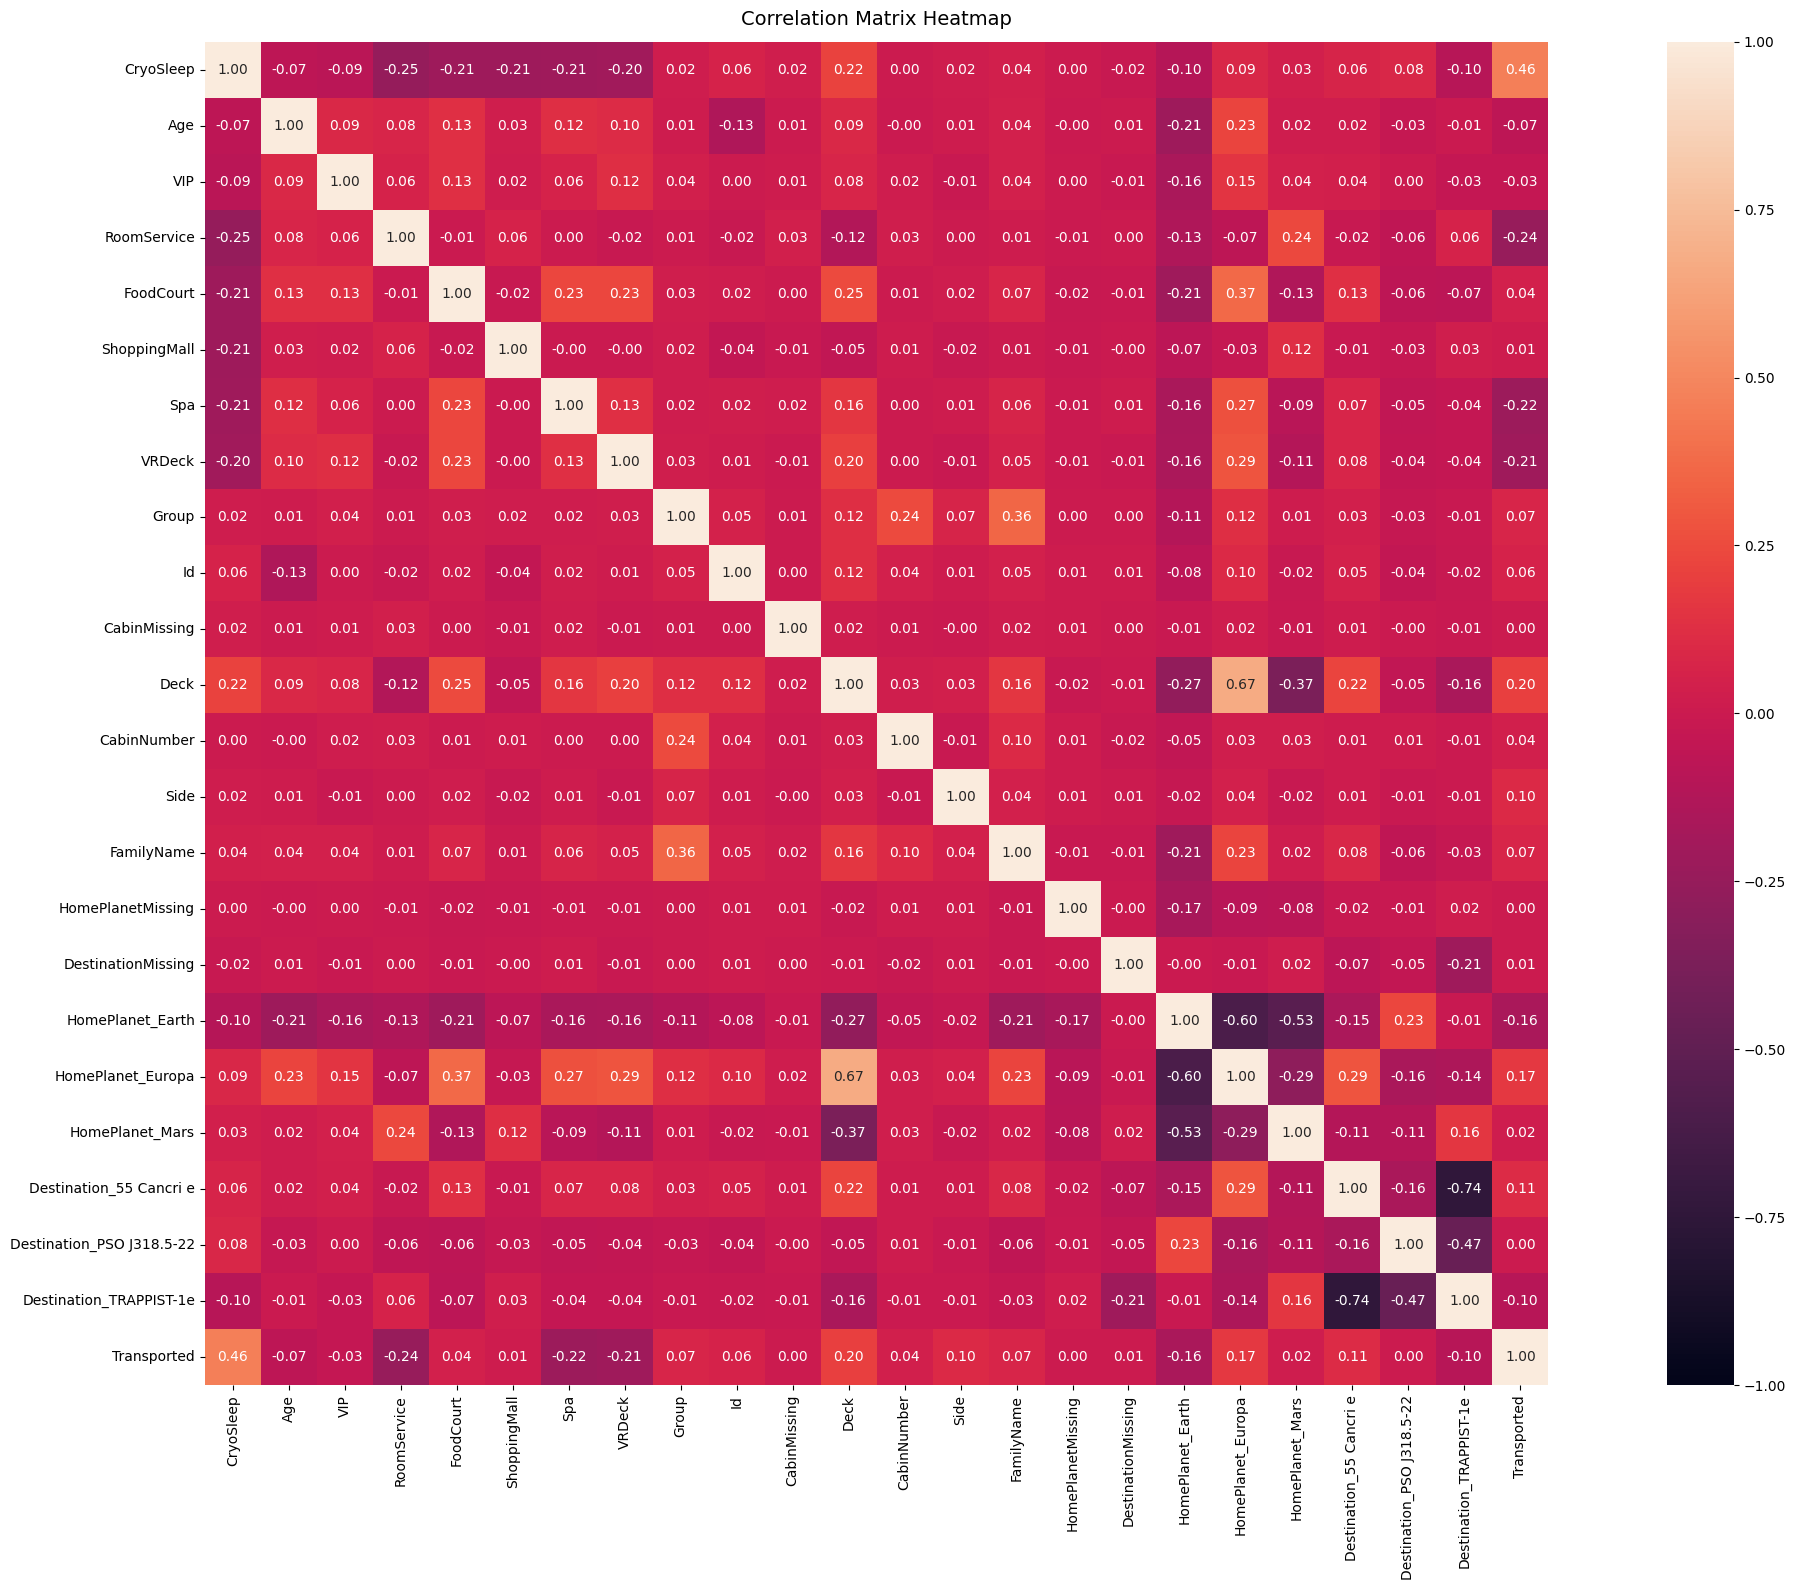

In [62]:
plt.figure(figsize=(24, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## **Feature Scaling**

In [38]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [39]:
cols_out = ['Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

In [65]:
scalers = [
    ColumnTransformer(transformers = [
        ('std_scaler', StandardScaler(),
         lambda X: [c for c in cols_out if c in X.columns])
        ], remainder="passthrough",
        verbose_feature_names_out=False),
    ColumnTransformer(transformers = [
        ('mm_scaler', MinMaxScaler(),
         lambda X: [c for c in cols_out if c in X.columns])
        ], remainder="passthrough",
        verbose_feature_names_out=False)
]

In [66]:
scores = []

for scaler in scalers:
  for model in models:
    pipeline = Pipeline([
        ("scaler", clone(scaler)),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))

      if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
      elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)
      else:
        raise ValueError(
            f"{type(model).__name__} does not provide a suitable ROC AUC score."
        )

      roc_auc.append(roc_auc_score(y_test, y_score))

    scores.append({
    "model": type(model).__name__,
    "scaler": scaler.transformers[0][0],
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    })

In [67]:
pd.DataFrame(scores)

,model,scaler,accuracy,f1,recall,precision,roc_auc
0,LogisticRegression,std_scaler,0.794546,0.800711,0.819552,0.782818,0.875365
1,RandomForestClassifier,std_scaler,0.795468,0.792307,0.774783,0.810705,0.879876
2,SVC,std_scaler,0.794777,0.798598,0.808132,0.789391,0.871183
3,KNeighborsClassifier,std_scaler,0.761762,0.764050,0.766104,0.762130,0.833644
4,XGBClassifier,std_scaler,0.789715,0.789657,0.783694,0.795848,0.881586
5,LogisticRegression,mm_scaler,0.767974,0.757868,0.721107,0.798670,0.852650
6,RandomForestClassifier,mm_scaler,0.795353,0.792308,0.775240,0.810211,0.879787
7,SVC,mm_scaler,0.750143,0.725827,0.656690,0.811317,0.838590
8,KNeighborsClassifier,mm_scaler,0.693548,0.688130,0.671311,0.705849,0.754301
9,XGBClassifier,mm_scaler,0.789715,0.789657,0.783694,0.795848,0.881586


Standard Scaler has proven to have better results than MinMax Scaler.

In [40]:
for X_train, y_train, X_test in zip(X_trains, y_trains, X_tests):
  std_scaler = StandardScaler()
  X_train[cols_out] = std_scaler.fit_transform(X_train[cols_out], y_train)
  X_test[cols_out] = std_scaler.transform(X_test[cols_out])

### Check correlation one more time

In [69]:
corr_matrix = pd.concat([X_trains[0],y_trains[0]],axis=1).corr()

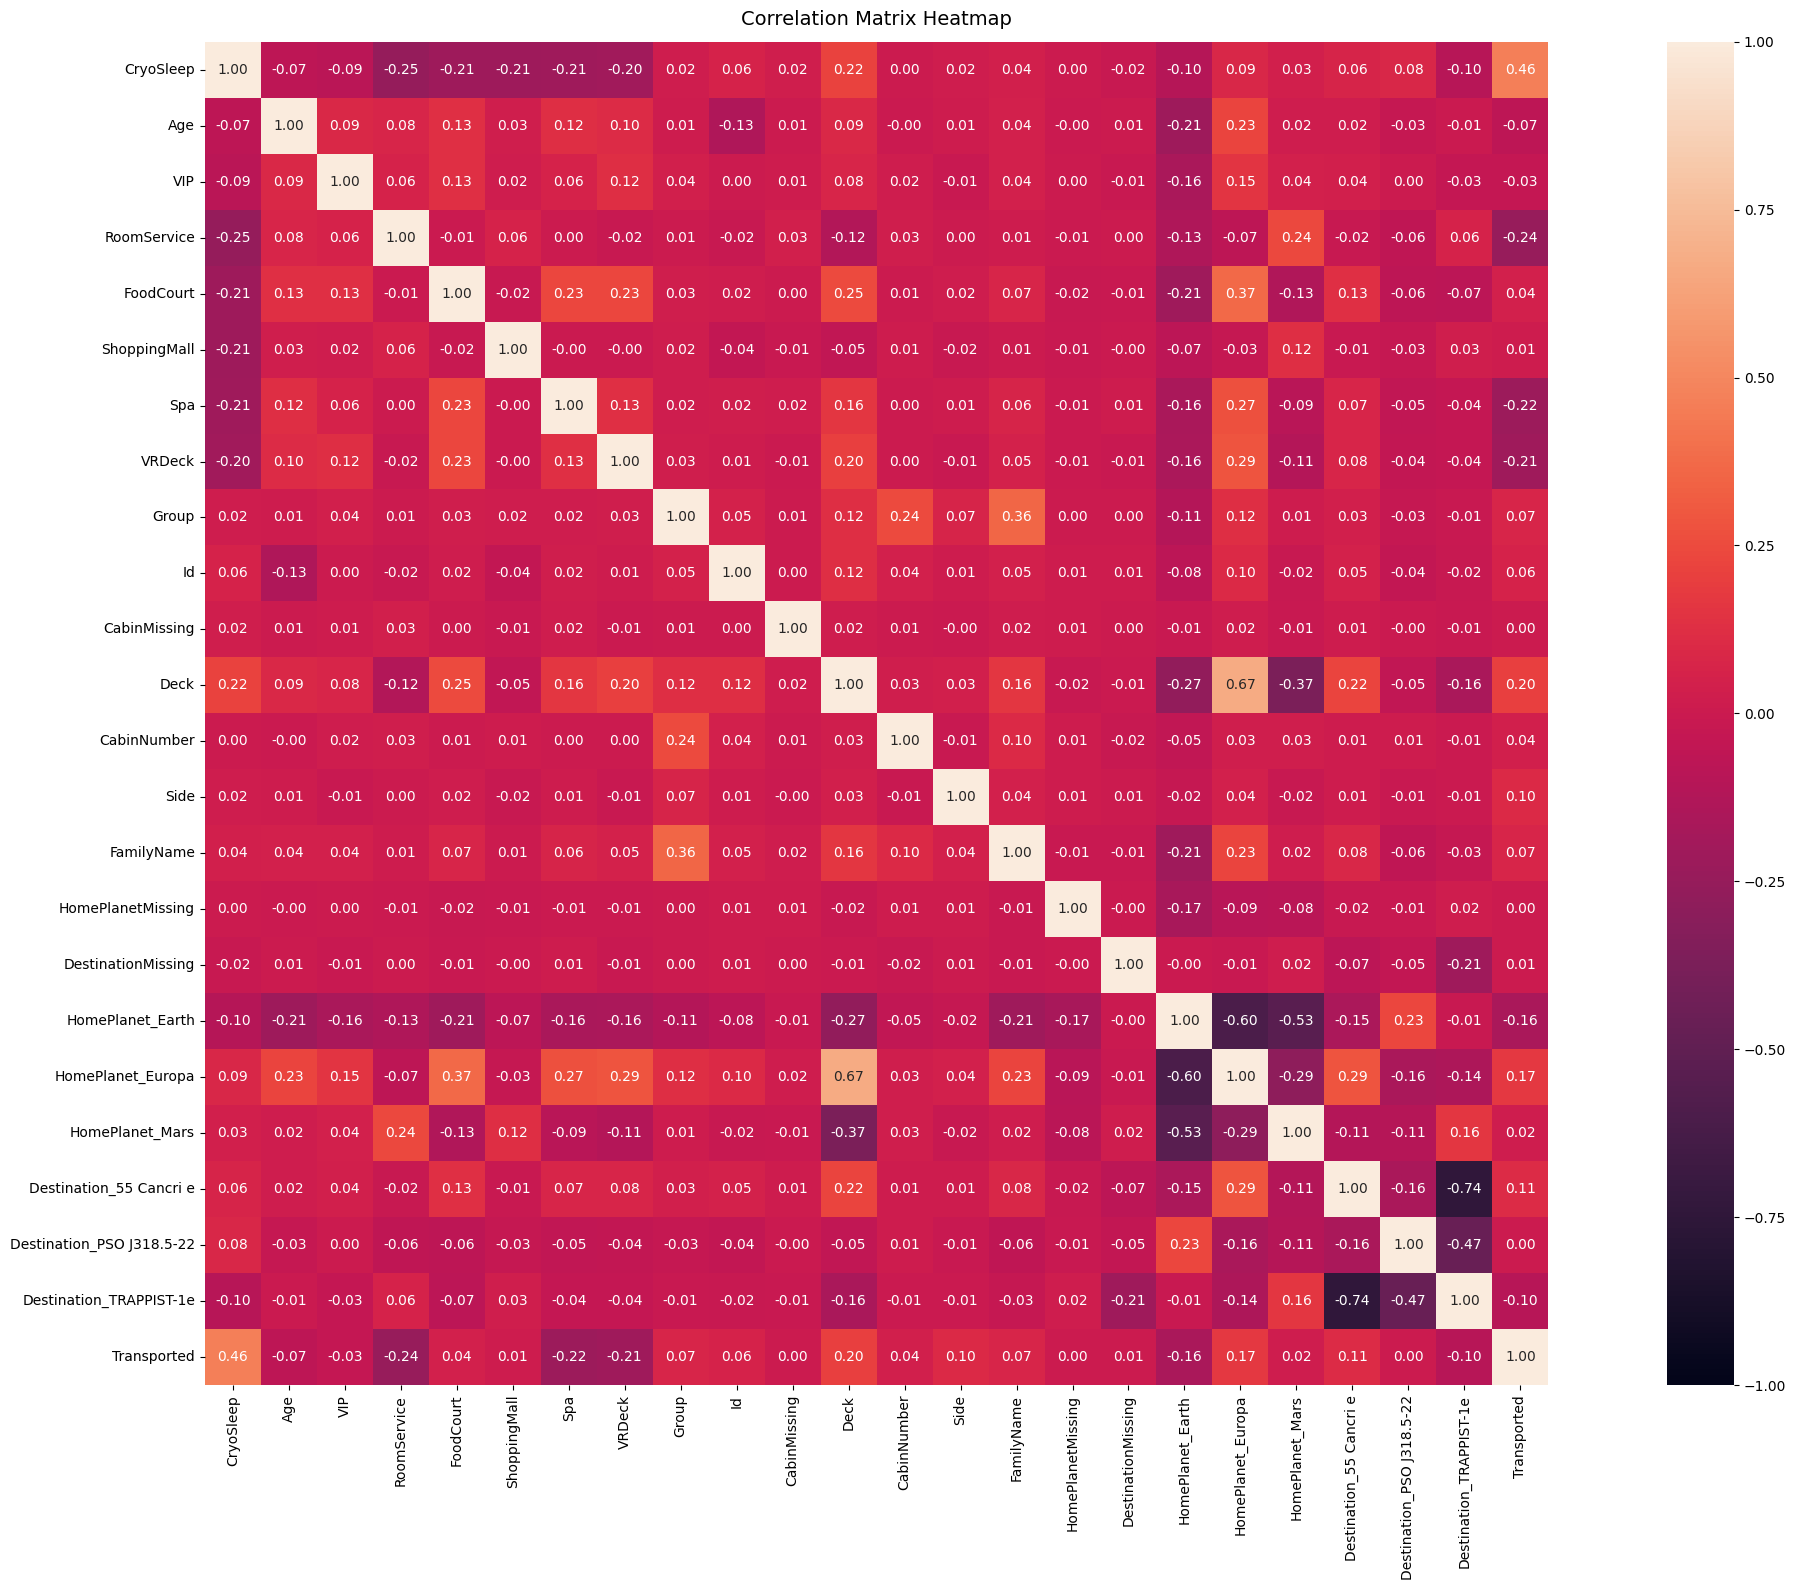

In [70]:
plt.figure(figsize=(24, 16))

sns.heatmap(
    corr_matrix,
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    square=True
)

plt.title('Correlation Matrix Heatmap', fontsize=14, pad=12)
plt.tight_layout()
plt.show()

## **Outlier detection**

In [41]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

In [42]:
detectors = [
    ('isolation_forest', IsolationForest()),
    ('local_outlier_factor', LocalOutlierFactor()),
    ('one_class_SVM', OneClassSVM()),
]

In [73]:
scores = []

for detector in detectors:
  for model in models:
    out_detector = clone(detector[1])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      mask = out_detector.fit_predict(X_train) == 1

      model.fit(X_train[mask], y_train[mask])

      y_pred = model.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))

      if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
      elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)
      else:
        raise ValueError(
            f"{type(model).__name__} does not provide a suitable ROC AUC score."
        )

      roc_auc.append(roc_auc_score(y_test, y_score))

    scores.append({
    "model": type(model).__name__,
    "detector": type(out_detector).__name__,
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    })

In [74]:
pd.DataFrame(scores)

,model,detector,accuracy,f1,recall,precision,roc_auc
0,LogisticRegression,IsolationForest,0.796502,0.803626,0.826861,0.781728,0.63572
1,RandomForestClassifier,IsolationForest,0.793973,0.791853,0.778212,0.806015,0.63572
2,SVC,IsolationForest,0.785919,0.792721,0.812929,0.773634,0.63572
3,KNeighborsClassifier,IsolationForest,0.761417,0.764304,0.768387,0.760434,0.63572
4,XGBClassifier,IsolationForest,0.784540,0.783817,0.775700,0.792173,0.63572
5,LogisticRegression,LocalOutlierFactor,0.794201,0.800584,0.820236,0.781935,0.63572
6,RandomForestClassifier,LocalOutlierFactor,0.795812,0.792965,0.776610,0.810073,0.63572
7,SVC,LocalOutlierFactor,0.793972,0.797265,0.804707,0.790081,0.63572
8,KNeighborsClassifier,LocalOutlierFactor,0.759921,0.762239,0.764277,0.760301,0.63572
9,XGBClassifier,LocalOutlierFactor,0.787300,0.786582,0.778670,0.794850,0.63572


## **Feature Selection**

In [ ]:
!pip install kydavra

In [44]:
from kydavra import (
    PValueSelector,
    PointBiserialCorrSelector,
)

In [45]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_is_fitted

class KydavraSelector(BaseEstimator, TransformerMixin):
    def __init__(self, selector):
        self.selector = selector

    def fit(self, X, y):
        X = X.copy()
        X["target"] = y.values if hasattr(y, "values") else y

        selected = self.selector.select(X, "target")
        self.selected_features_ = (
            selected if len(selected) > 0
            else list(X.drop(columns="target").columns)
        )
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_features_")
        return X[self.selected_features_]

    def get_feature_names_out(self, input_features=None):
        check_is_fitted(self, "selected_features_")
        return self.selected_features_

In [78]:
selects = [
    ('PValueSelector', PValueSelector()),
    ('PointBiserialCorrSelector', PointBiserialCorrSelector()),
]

selectors = [
    ColumnTransformer(
        transformers=[(i,KydavraSelector(j),all_cols)],
        remainder="passthrough",
        verbose_feature_names_out=False
        )
    for (i,j) in selects
]

In [79]:
scores = []

for selector in selectors:
  for model in models:
    pipeline = Pipeline([
        ("selector", clone(selector)),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []
    selected_cols = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))

      if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
      elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)
      else:
        raise ValueError(
            f"{type(model).__name__} does not provide a suitable ROC AUC score."
        )

      roc_auc.append(roc_auc_score(y_test, y_score))

      selected_cols.append(pipeline.named_steps["selector"].transformers_[0][1].get_feature_names_out())

    scores.append({
    "model": type(model).__name__,
    "selector": selector.transformers[0][0],
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    "selected_cols": selected_cols
    })

In [80]:
scores = pd.DataFrame(scores)
scores["num_cols"] = scores["selected_cols"].apply(
    lambda folds: len(folds[0])
)

In [81]:
scores

,model,selector,accuracy,f1,recall,precision,roc_auc,selected_cols,num_cols
0,LogisticRegression,PValueSelector,0.794201,0.800304,0.818867,0.782660,0.875480,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",18
1,RandomForestClassifier,PValueSelector,0.794893,0.790909,0.770904,0.812240,0.878271,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",18
2,SVC,PValueSelector,0.795006,0.800834,0.818411,0.784177,0.872510,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",18
3,KNeighborsClassifier,PValueSelector,0.765902,0.767900,0.769073,0.766830,0.840066,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",18
4,XGBClassifier,PValueSelector,0.788796,0.789605,0.787123,0.792204,0.881352,"[[CryoSleep, Age, RoomService, FoodCourt, Shop...",18
5,LogisticRegression,PointBiserialCorrSelector,0.763717,0.761771,0.751249,0.773506,0.826770,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
6,RandomForestClassifier,PointBiserialCorrSelector,0.767859,0.775773,0.797850,0.755699,0.833033,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
7,SVC,PointBiserialCorrSelector,0.774186,0.787179,0.829148,0.749293,0.807599,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
8,KNeighborsClassifier,PointBiserialCorrSelector,0.752332,0.750498,0.748070,0.758985,0.806364,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4
9,XGBClassifier,PointBiserialCorrSelector,0.770965,0.785163,0.830975,0.744170,0.845701,"[[CryoSleep, RoomService, Spa, VRDeck], [CryoS...",4


PValueSelector had selected all the columns - which is not what we wanted it to be like.

On the other hand, pointBiserialCorrSelector had worked pretty well, reducing the dimensions more than three times; however, it is better to work a little bit more on it so it takes in a little bit more features.

In [82]:
corrs = [
    # [0.1,0.9],
    # [0.2,0.9],
    [0,0.9],
    [0.99999,1],
]

scores = []

for corr in corrs:
  for model in models:
    pipeline = Pipeline([
        ("selector",
          ColumnTransformer(
            transformers=[('pbcs',
                           KydavraSelector(PointBiserialCorrSelector(min_corr=corr[0], max_corr=corr[1])),all_cols)],
            remainder="passthrough",
            verbose_feature_names_out=False
          )
        ),
        ("model", clone(model)),
    ])

    accuracy = []
    f1 = []
    recall = []
    precision = []
    roc_auc = []

    for X_train, y_train, X_test, y_test in zip(X_trains, y_trains, X_tests, y_tests):
      pipeline.fit(X_train, y_train)

      y_pred = pipeline.predict(X_test)

      accuracy.append(accuracy_score(y_test, y_pred))
      f1.append(f1_score(y_test, y_pred))
      recall.append(recall_score(y_test, y_pred))
      precision.append(precision_score(y_test, y_pred))

      if hasattr(pipeline, "predict_proba"):
        y_score = pipeline.predict_proba(X_test)[:, 1]
      elif hasattr(pipeline, "decision_function"):
        y_score = pipeline.decision_function(X_test)
      else:
        raise ValueError(
            f"{type(model).__name__} does not provide a suitable ROC AUC score."
        )

      roc_auc.append(roc_auc_score(y_test, y_score))

    scores.append({
    "model": type(model).__name__,
    "accuracy": np.mean(accuracy),
    "f1": np.mean(f1),
    "recall": np.mean(recall),
    "precision": np.mean(precision),
    "roc_auc": np.mean(roc_auc),
    "corrs": corr,
    "selected_cols": pipeline.named_steps["selector"].transformers_[0][1].get_feature_names_out()
    })

In [83]:
scores = pd.DataFrame(scores)
scores["num_cols"] = scores["selected_cols"].apply(len)

In [84]:
scores

,model,accuracy,f1,recall,precision,roc_auc,corrs,selected_cols,num_cols
0,LogisticRegression,0.763717,0.761771,0.751249,0.773506,0.826770,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
1,RandomForestClassifier,0.767859,0.775773,0.797850,0.755699,0.833033,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
2,SVC,0.774186,0.787179,0.829148,0.749293,0.807599,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
3,KNeighborsClassifier,0.752332,0.750498,0.748070,0.758985,0.806364,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
4,XGBClassifier,0.770965,0.785163,0.830975,0.744170,0.845701,"[0, 0.9]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
5,LogisticRegression,0.763717,0.761771,0.751249,0.773506,0.826770,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
6,RandomForestClassifier,0.767859,0.775773,0.797850,0.755699,0.833033,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
7,SVC,0.774186,0.787179,0.829148,0.749293,0.807599,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
8,KNeighborsClassifier,0.752332,0.750498,0.748070,0.758985,0.806364,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5
9,XGBClassifier,0.770965,0.785163,0.830975,0.744170,0.845701,"[0.99999, 1]","[CryoSleep, RoomService, Spa, VRDeck, Deck]",5


In [85]:
X_train.columns

Index(['CryoSleep', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall',
       'Spa', 'VRDeck', 'Group', 'Id', 'CabinMissing', 'Deck', 'CabinNumber',
       'Side', 'FamilyName', 'HomePlanetMissing', 'DestinationMissing',
       'HomePlanet_Earth', 'HomePlanet_Europa', 'HomePlanet_Mars',
       'Destination_55 Cancri e', 'Destination_PSO J318.5-22',
       'Destination_TRAPPIST-1e'],
      dtype='object')

In [46]:
from scipy.stats import pointbiserialr

for col in all_cols:
    corr, _ = pointbiserialr(y_train, X_train[col])
    print(col, corr)

CryoSleep 0.468817298221627
Age -0.06949455519600634
VIP -0.034859295965611034
RoomService -0.24836363398206918
FoodCourt 0.045247848746397416
ShoppingMall 0.00939221430502243
Spa -0.2211369682713835
VRDeck -0.2073450559435084
Group 0.07717465919461482
Id 0.0672034803965074
CabinMissing -0.0059543617920344485
Deck 0.21493261492783458
CabinNumber 0.07068335001974738
Side 0.10166700811019444
FamilyName 0.0674456067339112
HomePlanetMissing 0.0034781473453218913
DestinationMissing -0.006156040913283005
HomePlanet_Earth -0.1797091868011885
HomePlanet_Europa 0.19327588328694878
HomePlanet_Mars 0.014024381096072427
Destination_55 Cancri e 0.11219823805011664
Destination_PSO J318.5-22 -0.00031044972012923464
Destination_TRAPPIST-1e -0.09561374345841166


Kydavra doesn't work as expected :(

In [87]:
selected_cols = [
    'CryoSleep',
    'RoomService',
    'Spa',
    'VRDeck',
    'Deck',
]

Those are the one selected, but I'll take a bit more:

In [47]:
selected_cols = [
    'CryoSleep',
    'RoomService',
    'Spa',
    'VRDeck',
    'Deck',
    'HomePlanet_Earth',
    'HomePlanet_Europa',
    'Destination_55 Cancri e',
    'Destination_TRAPPIST-1e',
    'Side',
]

In [48]:
X_trains_sh = []
X_tests_sh = []

for (X_train, X_test) in zip(X_trains, X_tests):
  X_trains_sh.append(X_train[selected_cols])
  X_tests_sh.append(X_test[selected_cols])

# **Model Finetuning**

In [51]:
from sklearn.model_selection import GridSearchCV

For model finetuning will be used all 5 models.

### LogisticRegression

In [83]:
param_grid = {
    'classification__penalty': ['l2', 'l1']
}

In [84]:
p_lr = Pipeline([("classification", LogisticRegression(random_state=42))])

gscv = GridSearchCV(
    estimator=p_lr,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='accuracy',
    n_jobs=-1
    )

In [53]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__penalty': 'l2'}
Best cross-validation score:  0.7782651120482924


In [91]:
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
y_preds = []

best_model = LogisticRegression(random_state=42)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))

  y_pred_proba = best_model.predict_proba(X_test)[:, 1]
  roc_auc.append(roc_auc_score(y_test, y_pred_proba))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [55]:
pd.Series(scores)

,0
accuracy,0.781547
f1,0.784494
recall,0.789852
precision,0.779348
roc_auc,0.866317


### RandomForestClassifier

In [93]:
param_grid = {
    'classification__n_estimators': [100, 150, 200],
    'classification__max_features': ['auto', 'sqrt', 'log2'],
    'classification__max_depth': [4, 5, 6, 7, 8],
    'classification__criterion': ['gini', 'entropy']
}

In [94]:
p_rfc = Pipeline([("classification", RandomForestClassifier(random_state=42))])

gscv = GridSearchCV(
    estimator=p_rfc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='accuracy',
    n_jobs=-1
    )

In [58]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__criterion': 'entropy', 'classification__max_depth': 8, 'classification__max_features': 'sqrt', 'classification__n_estimators': 100}
Best cross-validation score:  0.7897663937815265


In [96]:
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
y_preds = []

best_model = RandomForestClassifier(random_state=42, max_depth=8, criterion='entropy', n_estimators=100)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))

  y_pred_proba = best_model.predict_proba(X_test)[:, 1]
  roc_auc.append(roc_auc_score(y_test, y_pred_proba))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [97]:
pd.Series(scores)

,0
accuracy,0.793742
f1,0.801104
recall,0.825488
precision,0.778371
roc_auc,0.876809


This one experiences overfitting, as the recall is higher than precision.

### SVC rbf

In [100]:
param_grid = {
    'classification__C': [0.1, 1, 10, 100],
    'classification__gamma': [0.1, 1, 10, 100]
}

In [101]:
p_svc = Pipeline([("classification", SVC(kernel='rbf', random_state=42))])

gscv = GridSearchCV(
    estimator=p_svc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='accuracy',
    n_jobs=-1
    )

In [63]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__C': 1, 'classification__gamma': 0.1}
Best cross-validation score:  0.7863162573389564


In [72]:
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
y_preds = []

best_model = SVC(kernel='rbf', random_state=42, C=1, gamma=0.1)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))

  y_pred_proba = best_model.decision_function(X_test)
  roc_auc.append(roc_auc_score(y_test, y_pred_proba))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [73]:
pd.Series(scores)

,0
accuracy,0.789714
f1,0.801883
recall,0.845358
precision,0.762737
roc_auc,0.863508


The results are pretty good, but it is overfitted - recall is much higher than precision.

### KNeighborsClassifier

In [105]:
param_grid = {
    'classification__n_neighbors': [5, 10, 20],
}

In [106]:
p_knc = Pipeline([("classification", KNeighborsClassifier())])

gscv = GridSearchCV(
    estimator=p_knc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='accuracy',
    n_jobs=-1
    )

In [68]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__n_neighbors': 20}
Best cross-validation score:  0.7694885470933598


In [70]:
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
y_preds = []

best_model = KNeighborsClassifier(n_neighbors=20)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))

  y_pred_proba = best_model.predict_proba(X_test)[:, 1]
  roc_auc.append(roc_auc_score(y_test, y_pred_proba))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [71]:
pd.Series(scores)

,0
accuracy,0.768088
f1,0.762333
recall,0.739388
precision,0.787825
roc_auc,0.861840


### XGBClassifier

In [110]:
param_grid = {
    'classification__n_estimators': [50, 100, 150],
    'classification__colsample_bytree': [0.1, 0.25, 0.5],
    'classification__max_depth': [4, 5, 6, 7, 8],
    'classification__criterion': ['gini', 'entropy']
}

In [111]:
p_rfc = Pipeline([("classification", xgb.XGBClassifier())])

gscv = GridSearchCV(
    estimator=p_rfc,
    param_grid=param_grid,
    cv=StratifiedKFold(10),
    scoring='accuracy',
    n_jobs=-1
    )

In [76]:
gscv.fit(X_trains_sh[0], y_trains[0])

print("Best parameters found: ", gscv.best_params_)
print("Best cross-validation score: ", gscv.best_score_)

Best parameters found:  {'classification__colsample_bytree': 0.5, 'classification__criterion': 'gini', 'classification__max_depth': 6, 'classification__n_estimators': 50}
Best cross-validation score:  0.7878975440337385


In [123]:
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
y_preds = []

best_model = xgb.XGBClassifier(criterion='gini', colsample_bytree=0.5, max_depth=6, n_estimators=50)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))

  y_pred_proba = best_model.predict_proba(X_test)[:, 1]
  roc_auc.append(roc_auc_score(y_test, y_pred_proba))

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [124]:
pd.Series(scores)

,0
accuracy,0.789139
f1,0.798176
recall,0.828457
precision,0.770147
roc_auc,0.876463


# **Final Best Results**

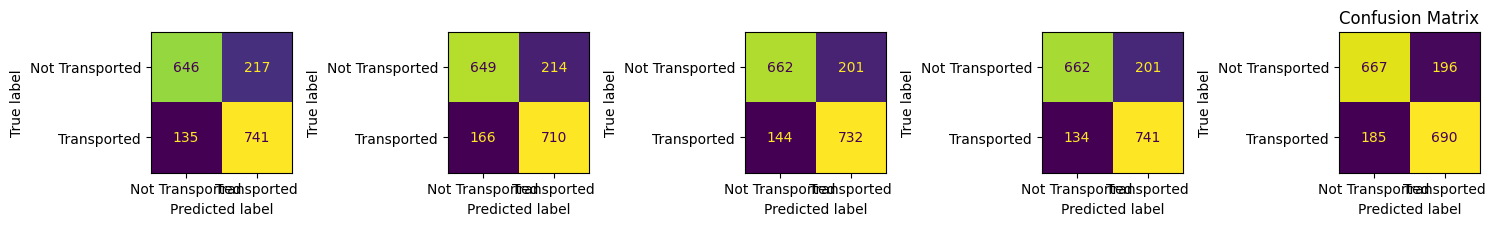

In [125]:
accuracy = []
f1 = []
recall = []
precision = []
roc_auc = []
y_preds = []

best_model = RandomForestClassifier(random_state=42, max_depth=8, criterion='entropy', n_estimators=100)

for (X_train, y_train, X_test, y_test) in zip(X_trains_sh, y_trains, X_tests_sh, y_tests):
  best_model.fit(X_train, y_train)
  y_pred = best_model.predict(X_test)

  accuracy.append(accuracy_score(y_test, y_pred))
  f1.append(f1_score(y_test, y_pred))
  recall.append(recall_score(y_test, y_pred))
  precision.append(precision_score(y_test, y_pred))
  y_preds.append(y_pred)

  y_pred_proba = best_model.predict_proba(X_test)[:, 1]
  roc_auc.append(roc_auc_score(y_test, y_pred_proba))

plot_conf_matrix(y_tests, y_preds, 'Confusion Matrix',
                ['Not Transported', 'Transported'])

scores = ({
"accuracy": np.mean(accuracy),
"f1": np.mean(f1),
"recall": np.mean(recall),
"precision": np.mean(precision),
"roc_auc": np.mean(roc_auc),
})

In [126]:
pd.Series(scores)

,0
accuracy,0.793742
f1,0.801104
recall,0.825488
precision,0.778371
roc_auc,0.876809


RandomForestClassifier has achieved the greatest overall results. It seems a little bit overfitted, but overall OK.

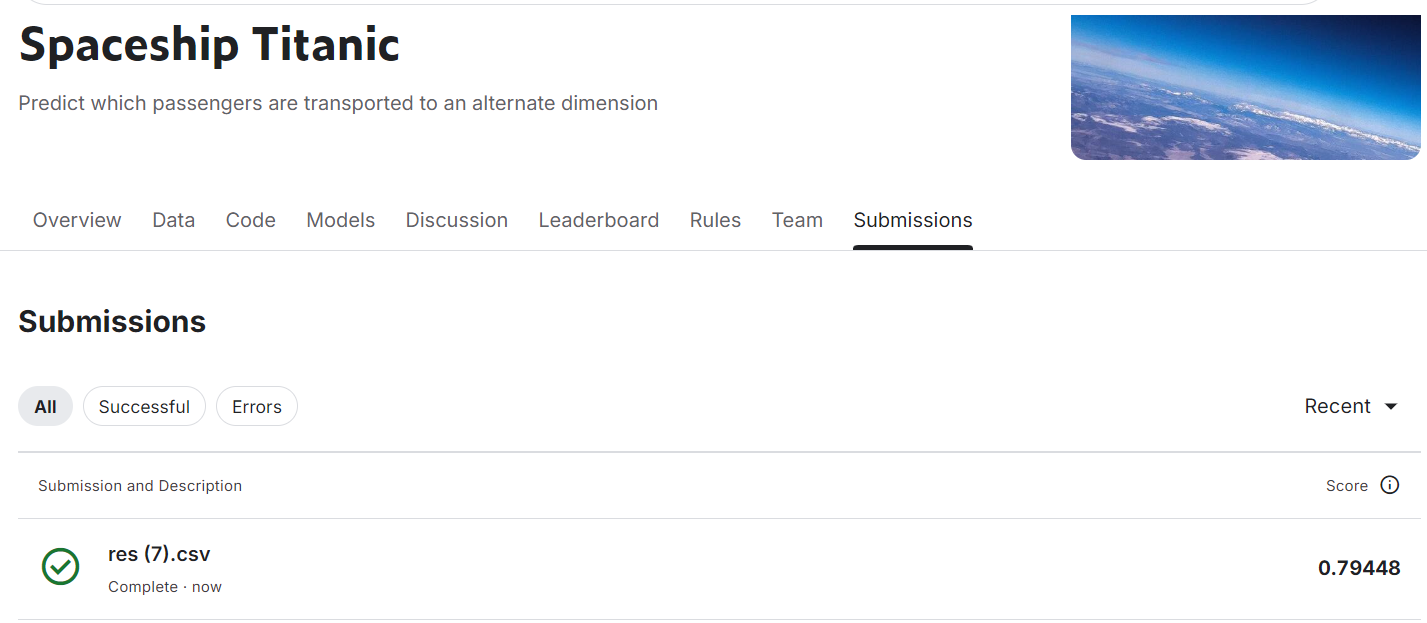

# **Conclusion**

Data Analysis, Data Preprocessing, and Machine Learning are all important, each in its own way.

Graphs help us understand what the data actually looks like — how it's distributed, whether there are patterns worth noting. Business logic also shows up during Data Analysis: what will this data be used for — classification or prediction? Is the target we want to predict continuous or binary? Answering these questions early makes a big difference once we get to the actual modeling. This stage is also where we catch meaningful details, like whether there are outliers, or erroneous, inconsistent, or missing data.

With a full understanding of what's going on, we move into one of the most difficult and interesting parts — Data Preprocessing. Most models only work with numerical data, but we often have text or categorical features. What do we do? We encode them, taking cardinality into account: for low-cardinality categories, one-hot encoding is usually a good fit, while for high-cardinality ones, target encoding tends to work better. Some models also can't handle missing data, so we turn to imputers — chosen based on the situation, ranging from something simple like a median imputer to something more sophisticated like a KNN imputer.

Then comes the ML itself. Depending on the result we're trying to predict, we choose between regressors or classifiers. And based on the insights from Data Analysis, we choose the type of algorithm — linear models, SVMs, tree-based methods, k-nearest neighbors, or more advanced approaches like XGBoost (which is also tree-based).

In conclusion, Data Analysis, Data Preprocessing, and Machine Learning are three closely connected stages, each depending on the results of the one before it. A good understanding of the data leads to smarter preprocessing choices, and clean, well-prepared data is what allows a model to actually learn meaningful patterns instead of noise. None of these steps work well in isolation — skipping or rushing through EDA or preprocessing usually shows up later as poor model performance, which is often why in practice we end up returning to earlier steps after seeing the first results, rather than moving through them just once.